<a href="https://colab.research.google.com/github/NahomiHM/Procesos-estocasticos/blob/main/Descomposici%C3%B3ncanonica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Descomposición Canónica

1. Escriba la matriz P de la imagen anexa y dibuje su diagrama de transiciones.

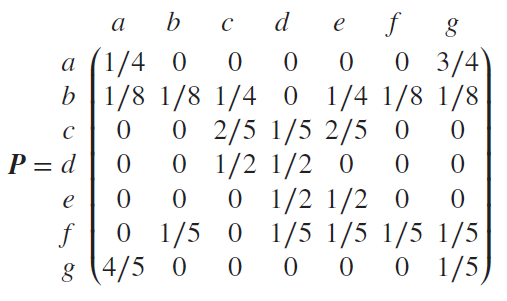

In [ ]:
import sympy as sp
import networkx as nx
import matplotlib.pyplot as plt

# Definir la matriz P
#rational nos ayuda a poner en fracciones
P = sp.Matrix([
    [sp.Rational(1,4), 0, 0, 0, 0, 0, sp.Rational(3,4)],
    [sp.Rational(1,8), sp.Rational(1,8), sp.Rational(1,4), 0, sp.Rational(1,4), sp.Rational(1,8), sp.Rational(1,8)],
    [0, 0, sp.Rational(2,5), sp.Rational(1,5), sp.Rational(2,5), 0, 0],
    [0, 0, sp.Rational(1,2), sp.Rational(1,2), 0, 0, 0],
    [0, 0, 0, sp.Rational(1,2), sp.Rational(1,2), 0, 0],
    [0, sp.Rational(1,5), 0, sp.Rational(1,5), sp.Rational(1,5), sp.Rational(1,5), sp.Rational(1,5)],
    [sp.Rational(4,5), 0, 0, 0, 0, 0, sp.Rational(1,5)]
])
P #imprimimos la matriz

Matrix([
[1/4,   0,   0,   0,   0,   0, 3/4],
[1/8, 1/8, 1/4,   0, 1/4, 1/8, 1/8],
[  0,   0, 2/5, 1/5, 2/5,   0,   0],
[  0,   0, 1/2, 1/2,   0,   0,   0],
[  0,   0,   0, 1/2, 1/2,   0,   0],
[  0, 1/5,   0, 1/5, 1/5, 1/5, 1/5],
[4/5,   0,   0,   0,   0,   0, 1/5]])

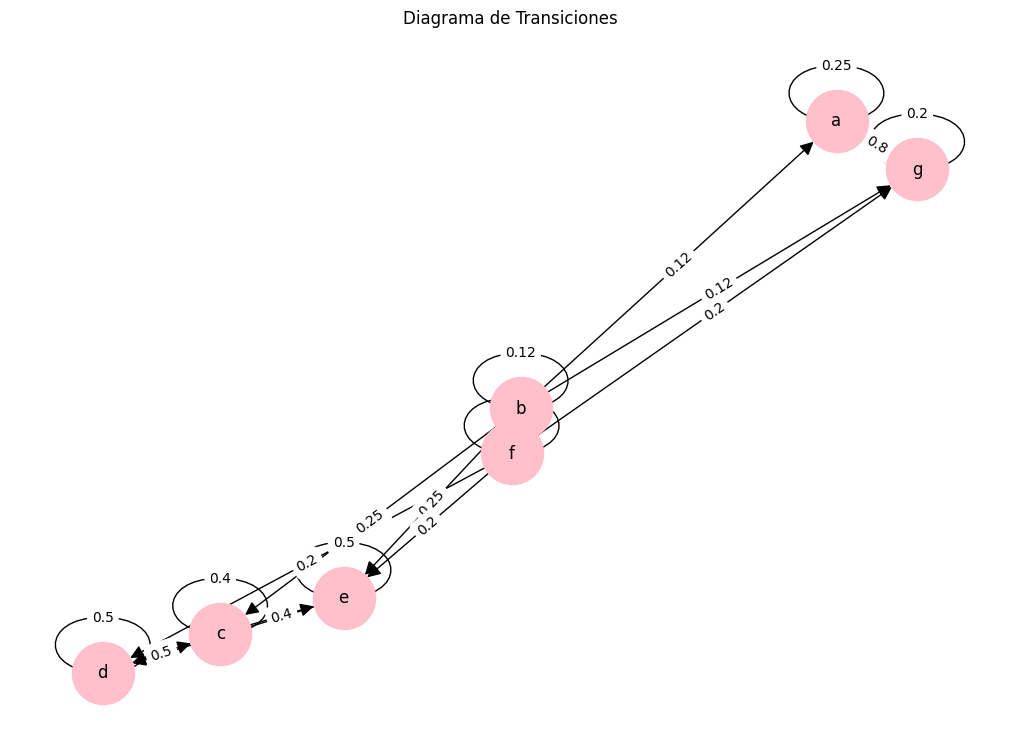

In [ ]:
# Dibujar el diagrama de transiciones
def dibujar_diagrama(matriz):
    G = nx.DiGraph()
    labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g'] #etiquetas
    for i in range(matriz.rows): #usando la matriz
        for j in range(matriz.cols):
            prob = matriz[i, j]
            if prob > 0:
                G.add_edge(labels[i], labels[j], weight=float(prob))

    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(10, 7))
    nx.draw(G, pos, with_labels=True, node_color='pink', node_size=2000, arrowsize=20)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels={k: round(v, 2) for k, v in edge_labels.items()})
    plt.title("Diagrama de Transiciones")
    plt.show()

dibujar_diagrama(P)

 identificamos las clases de equivalencia:


*   Clases Recurrentes: Grupos de estados de los que no se puede salir una vez que entras.

$\{a, g\}$ es una clase recurrente (se comunican entre sí y no salen a otros).$\{c, d, e\}$ es otra clase recurrente.
*  Clases Transitorias: Estados que eventualmente llevan a las recurrentes.

$\{b, f\}$ son estados transitorios.


  

2 Determine si la matriz tiene o no distribución límite.
. Escriba la descomposición canónica de la matriz, determine el límite de la potencia n-esima y compare contra las distribuciones límite de las submatrices.

In [ ]:
def analizar_limite_y_canonica(matriz):
    # La matriz tiene distribución límite si es aperiódica y tiene clases recurrentes
    # Calculamos P^n para un n grande simbólicamente
    print("Distribución Límite:")
    # Para cadenas con múltiples clases recurrentes, el límite depende del estado inicial.

    # Reordenamiento para forma canónica: [ R | 0 ]
    #                                     [ S | Q ]
    # Orden propuesto: (a, g), (c, d, e), (b, f)
    indices = [0, 6, 2, 3, 4, 1, 5]
    P_canonica = matriz[indices, indices]

    print("Matriz en Forma Canónica (Orden: a, g, c, d, e, b, f):")
    display(P_canonica)

    # Límite de P^n
    # Para las submatrices recurrentes, el límite es su distribución estacionaria
    P_inf = matriz**100 # Aproximación numérica/simbólica de potencia n-ésima
    print("Límite de la potencia n-ésima (P^inf):")
    display(P_inf.evalf(subs=None, maxn=2))

analizar_limite_y_canonica(P)

Distribución Límite:
Matriz en Forma Canónica (Orden: a, g, c, d, e, b, f):


Matrix([
[1/4, 3/4,   0,   0,   0,   0,   0],
[4/5, 1/5,   0,   0,   0,   0,   0],
[  0,   0, 2/5, 1/5, 2/5,   0,   0],
[  0,   0, 1/2, 1/2,   0,   0,   0],
[  0,   0,   0, 1/2, 1/2,   0,   0],
[1/8, 1/8, 1/4,   0, 1/4, 1/8, 1/8],
[  0, 1/5,   0, 1/5, 1/5, 1/5, 1/5]])

Límite de la potencia n-ésima (P^inf):


Matrix([
[0.516129032258065,                    0,                 0,                 0,                 0,                    0, 0.483870967741935],
[0.172043010752688, 5.93420779787646e-50, 0.222222222222222, 0.266666666666667, 0.177777777777778, 5.93420779787646e-50, 0.161290322580645],
[                0,                    0, 0.333333333333333,               0.4, 0.266666666666667,                    0,                 0],
[                0,                    0, 0.333333333333333,               0.4, 0.266666666666667,                    0,                 0],
[                0,                    0, 0.333333333333333,               0.4, 0.266666666666667,                    0,                 0],
[0.172043010752688, 9.49473247660234e-50, 0.222222222222222, 0.266666666666667, 0.177777777777778, 9.49473247660234e-50, 0.161290322580645],
[0.516129032258065,                    0,                 0,                 0,                 0,                    0, 0.483870967741935]])

Escriba un programa que encuentre la descomposición canónica de una matriz dada.

In [ ]:
def programa_descomposicion_automatica(matriz):
    import numpy as np
    # Convertir a grafo para usar algoritmos de red
    adj = np.array(matriz.tolist()).astype(float)
    G = nx.from_numpy_array(adj, create_using=nx.DiGraph)

    # 1. Encontrar componentes fuertemente conexos (clases)
    clases = list(nx.strongly_connected_components(G))

    recurrentes = []
    transitorios = []

    # 2. Determinar si la clase es recurrente
    # Una clase es recurrente si no hay aristas que salgan de ella hacia otra clase
    for clase in clases:
        es_recurrente = True
        for nodo in clase:
            for vecino in G.neighbors(nodo):
                if vecino not in clase:
                    es_recurrente = False
                    break
        if es_recurrente:
            recurrentes.append(clase)
        else:
            transitorios.append(clase)

    print(f"Clases Recurrentes: {recurrentes}")
    print(f"Clases Transitorias: {transitorios}")

    # 3. Construir la matriz reordenada
    orden_final = []
    for r in recurrentes: orden_final.extend(list(r))
    for t in transitorios: orden_final.extend(list(t))

    return matriz[orden_final, orden_final]

# Probar con la matriz P
P_res = programa_descomposicion_automatica(P)
display(P_res)

Clases Recurrentes: [{0, 6}, {2, 3, 4}]
Clases Transitorias: [{1, 5}]


Matrix([
[1/4, 3/4,   0,   0,   0,   0,   0],
[4/5, 1/5,   0,   0,   0,   0,   0],
[  0,   0, 2/5, 1/5, 2/5,   0,   0],
[  0,   0, 1/2, 1/2,   0,   0,   0],
[  0,   0,   0, 1/2, 1/2,   0,   0],
[1/8, 1/8, 1/4,   0, 1/4, 1/8, 1/8],
[  0, 1/5,   0, 1/5, 1/5, 1/5, 1/5]])